# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test4 exposure

Notebook equivalent of `tests/4_earth/test4_exposure.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test4_exposure"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test4_exposure.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test4_exposure


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_make_eta_grid_and_daynight_slices`

**What is checked:** Make eta grid and daynight slices behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Full eta grid must contain ns points; Day slice for ns=9 must contain ceil/floor upper half; Night slice for ns=9 must contain lower half; Eta grid must be sorted increasingly.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_make_eta_grid_and_daynight_slices)


Running test_make_eta_grid_and_daynight_slices ...

Eta grids:
full : tensor([0.0000000000e+00, 3.9269908170e-01, 7.8539816340e-01, 1.1780972451e+00, 1.5707963268e+00, 1.9634954085e+00, 2.3561944902e+00, 2.7488935719e+00, 3.1415926536e+00],
       dtype=torch.float64)
day  : tensor([1.9634954085e+00, 2.3561944902e+00, 2.7488935719e+00, 3.1415926536e+00], dtype=torch.float64)
night: tensor([0.0000000000e+00, 3.9269908170e-01, 7.8539816340e-01, 1.1780972451e+00], dtype=torch.float64)
Checking: Eta grid starts at zero
  actual shape  : ()
  expected shape: ()
  max abs diff  : 0.000000e+00
Checking: Eta grid ends at pi
  actual shape  : ()
  expected shape: ()
  max abs diff  : 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_make_eta_grid_and_daynight_slices


## Test: `test_indefinite_integral_day_is_finite`

**What is checked:** Indefinite integral day is finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: IndefiniteIntegralDay must return a complex tensor; Primitive real part must be finite; Primitive imaginary part must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_indefinite_integral_day_is_finite)


Running test_indefinite_integral_day_is_finite ...

IndefiniteIntegralDay:
T     : 0.15
eta   : 1.0
lambda: 0.72
value : tensor(2.6596807448e+00+2.6838481805e+00j, dtype=torch.complex128)
------------------------------------------------------------------------------------------
PASSED: test_indefinite_integral_day_is_finite


## Test: `test_integral_angle_and_day_are_finite`

**What is checked:** Integral angle and day are finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: IntegralAngle must return a scalar for scalar eta; IntegralDay must return a scalar for scalar eta; IntegralAngle output must be finite; IntegralDay output must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_integral_angle_and_day_are_finite)


Running test_integral_angle_and_day_are_finite ...

Analytical exposure weights:
IntegralAngle: tensor(5.7790660366e+00, dtype=torch.float64)
IntegralDay  : tensor(9.1323734581e+00, dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_integral_angle_and_day_are_finite


## Test: `test_nadir_exposure_table_normalization_and_interp`

**What is checked:** Nadir exposure table normalization and interp behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Table device property is correct; Table dtype property is correct; Normalized exposure must integrate to one; Interpolated exposure must match query shape; and additional consistency checks.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues.


In [7]:
run_notebook_test(TEST_MODULE.test_nadir_exposure_table_normalization_and_interp)


Running test_nadir_exposure_table_normalization_and_interp ...

NadirExposureTable normalization and interpolation:
raw integral       : 2.3561944902
normalized integral: 1.0000000000
query eta          : tensor([0.0000000000e+00, 5.0000000000e-01, 1.0000000000e+00, 2.0000000000e+00, 3.1415926536e+00], dtype=torch.float64)
interpolated W     : tensor([1.0610329539e-01, 2.0440946247e-01, 4.0554829065e-01, 4.5560497714e-01, 1.0610329539e-01], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_nadir_exposure_table_normalization_and_interp


## Test: `test_nadir_exposure_from_math_shapes_and_finiteness`

**What is checked:** Nadir exposure from math shapes and finiteness behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Math eta table must have ns points; Math exposure shape must match eta shape; Math exposure must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_nadir_exposure_from_math_shapes_and_finiteness)


Running test_nadir_exposure_from_math_shapes_and_finiteness ...

nadir_exposure_from_math:
eta shape     : (7,)
exposure shape: (7,)
eta           : tensor([0.0000000000e+00, 5.2359877560e-01, 1.0471975512e+00, 1.5707963268e+00, 2.0943951024e+00, 2.6179938780e+00, 3.1415926536e+00], dtype=torch.float64)
exposure      : tensor([0.0000000000e+00, 4.6752494891e+00, 1.0108640095e+01, 9.0293337681e+00, 1.0108640095e+01, 4.6752494888e+00, 0.0000000000e+00], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_nadir_exposure_from_math_shapes_and_finiteness


## Test: `test_build_nadir_exposure_math_without_cache`

**What is checked:** Build nadir exposure math without cache behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Math builder must return NadirExposureTable; Math builder eta shape is correct; Math builder exposure shape is correct; Math builder exposure must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_build_nadir_exposure_math_without_cache)


Running test_build_nadir_exposure_math_without_cache ...

build_nadir_exposure(source='math', use_cache=False):
table type: <class 'tpeanuts.earth.exposure.NadirExposureTable'>
eta shape : (7,)
W shape   : (7,)
W min/max : 0.0 10.108640095185187
------------------------------------------------------------------------------------------
PASSED: test_build_nadir_exposure_math_without_cache


## Test: `test_build_nadir_exposure_csv_modes_and_daynight`

**What is checked:** Build nadir exposure csv modes and daynight behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: CSV Nadir table must keep all points; CSV Zenith table must keep all points; CSV night table must keep the lower half; CSV normalized exposure integrates to one.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [10]:
run_notebook_test(TEST_MODULE.test_build_nadir_exposure_csv_modes_and_daynight)


Running test_build_nadir_exposure_csv_modes_and_daynight ...
Created temporary CSV file: V:\output\test\earth\test4_exposure\synthetic_exposure.csv

CSV exposure tables:
nadir eta shape : (9,)
zenith exposure : tensor([2.0000000000e+00, 1.8750000000e+00, 1.7500000000e+00, 1.6250000000e+00, 1.5000000000e+00, 1.3750000000e+00, 1.2500000000e+00, 1.1250000000e+00, 1.0000000000e+00],
       dtype=torch.float64)
night eta       : tensor([0.0000000000e+00, 3.9269908170e-01, 7.8539816340e-01, 1.1780972451e+00], dtype=torch.float64)
normalized area : 1.0
Checking: Zenith mode reverses exposure values
  actual shape  : (9,)
  expected shape: (9,)
  max abs diff  : 0.000000e+00
------------------------------------------------------------------------------------------
PASSED: test_build_nadir_exposure_csv_modes_and_daynight


## Test: `test_invalid_inputs_raise_errors`

**What is checked:** Invalid inputs raise errors behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [11]:
run_notebook_test(TEST_MODULE.test_invalid_inputs_raise_errors)


Running test_invalid_inputs_raise_errors ...

Invalid input checks:
IntegralDay with d1 > d2 should raise ValueError
build_nadir_exposure(source='math') without lam_rad should raise ValueError
build_nadir_exposure(source='csv') without csv_path should raise ValueError
------------------------------------------------------------------------------------------
PASSED: test_invalid_inputs_raise_errors


## Plot: `plot_math_exposure_profiles()`

**What is checked:** Math exposure profiles behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_exposure_math_profiles.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_math_exposure_profiles()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_exposure_math_profiles.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_math_exposure_profiles() ...
Saved plot: V:\output\test\earth\test4_exposure\plot_math_exposure_profiles_figure_001.png


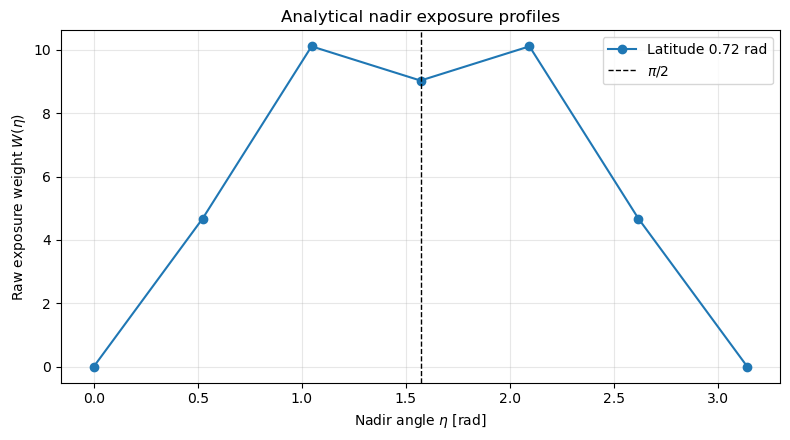

PASSED: plot_math_exposure_profiles()


In [12]:
run_notebook_call('plot_math_exposure_profiles()', lambda: TEST_MODULE.plot_math_exposure_profiles())


## Plot: `plot_table_interpolation()`

**What is checked:** Table interpolation behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_exposure_table_interpolation.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_table_interpolation()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_exposure_table_interpolation.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_table_interpolation() ...
Saved plot: V:\output\test\earth\test4_exposure\plot_table_interpolation_figure_001.png


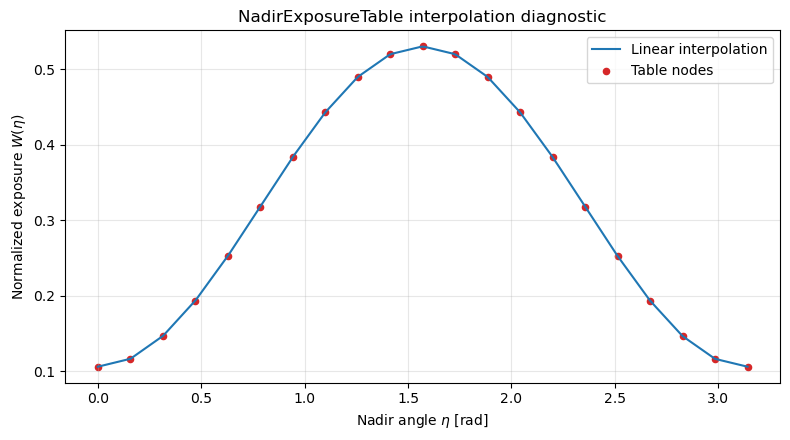

PASSED: plot_table_interpolation()


In [13]:
run_notebook_call('plot_table_interpolation()', lambda: TEST_MODULE.plot_table_interpolation())


## Plot: `plot_csv_angle_modes()`

**What is checked:** Csv angle modes behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_exposure_csv_angle_modes.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_csv_angle_modes()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_exposure_csv_angle_modes.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_csv_angle_modes() ...
Created temporary CSV file: V:\output\test\earth\test4_exposure\synthetic_exposure_plot.csv
Saved plot: V:\output\test\earth\test4_exposure\plot_csv_angle_modes_figure_001.png


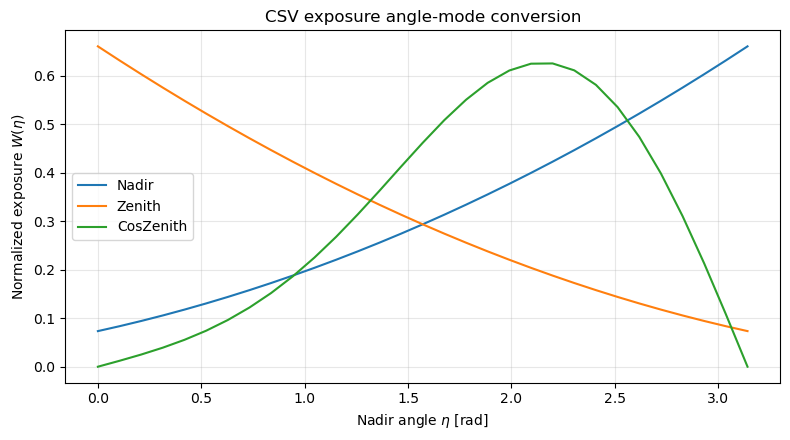

PASSED: plot_csv_angle_modes()


In [14]:
run_notebook_call('plot_csv_angle_modes()', lambda: TEST_MODULE.plot_csv_angle_modes())
